In [26]:
import time
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import lovelyplots
from qiskit.circuit.library import CXGate
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.synthesis.two_qubit.xx_decompose import XXDecomposer
from tqdm import trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.isa import DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer

logger.setLevel("INFO")


In [27]:
# === ISA CONFIGURATION ===
# Uncomment/modify the strengths you want to benchmark
# Strength = pi/2 corresponds to full CX, pi/4 to sqrt(CX), etc.

STRENGTHS = [
    np.pi / 2,  # CX - power 1
    np.pi / 4,  # sqrt(CX) - power 1/2
    np.pi / 6,  # power 1/3
    # np.pi / 8,  # power 1/4
    # np.pi / 12,  # power 1/6
]

# Number of random unitaries to test
N = 1000

# Fidelity threshold for flagging failures
FIDELITY_THRESHOLD = 1 - 1e-8

# gulps_decomposer.isa.max_depth = 16

In [28]:
# ### Helper Functions

# %%
def strength_to_cx_power(strength):
    """Convert XX strength (radians) to CX gate power.

    CX corresponds to XX(pi/2), so:
    - strength = pi/2 -> power = 1
    - strength = pi/4 -> power = 1/2
    - strength = pi/k -> power = 1/(k/2) = 2/k
    """
    return strength / (np.pi / 2)


def create_xx_decomposer(strengths):
    """Create XXDecomposer with given strengths.

    Uses near-perfect fidelities (slope/offset model from draft).
    """
    slope, offset = 1e-10, 1e-12
    basis_fidelity = {s: 1.0 - (slope * s / (np.pi / 2) + offset) for s in strengths}
    return XXDecomposer(basis_fidelity), basis_fidelity


def create_gulps_decomposer(strengths):
    """Create GulpsDecomposer with gates corresponding to given strengths."""
    gate_set = []
    costs = []
    names = []

    for s in strengths:
        power = strength_to_cx_power(s)
        gate_set.append(CXGate().power(power))
        costs.append(power)  # cost proportional to gate "duration"

        # Create readable name
        if power == 1:
            names.append("cx")
        elif power == 0.5:
            names.append("sqrt_cx")
        else:
            # Express as fraction if clean
            from fractions import Fraction

            frac = Fraction(power).limit_denominator(100)
            names.append(f"cx^{frac}")

    isa = DiscreteISA(gate_set, costs, names, precompute_polytopes=False)
    return GulpsDecomposer(isa=isa), isa


In [29]:
### Initialize Decomposers

# %%
print(f"ISA Strengths: {[f'π/{int(np.pi / s):.0f}' for s in STRENGTHS]}")
print(f"CX Powers: {[strength_to_cx_power(s) for s in STRENGTHS]}")
print()

# Create both decomposers
xx_decomposer, basis_fidelity = create_xx_decomposer(STRENGTHS)
gulps_decomposer, isa = create_gulps_decomposer(STRENGTHS)

print("XXDecomposer basis_fidelity:")
for s, f in basis_fidelity.items():
    print(f"  {s:.6f} rad (π/{np.pi / s:.1f}): {f:.12f}")

print(f"\nGulpsDecomposer ISA gates: {[g.name for g in isa.gate_set]}")

ISA Strengths: ['π/2', 'π/4', 'π/6']
CX Powers: [1.0, 0.5, 0.3333333333333333]

XXDecomposer basis_fidelity:
  1.570796 rad (π/2.0): 0.999999999899
  0.785398 rad (π/4.0): 0.999999999949
  0.523599 rad (π/6.0): 0.999999999966

GulpsDecomposer ISA gates: ['cx', 'sqrt_cx', 'cx^1/3']


In [30]:
# ### Warm-up (JIT compilation, caches, etc.)
print("Warming up decomposers...")
for i in range(10):
    u = random_unitary(4, seed=i + 10000)
    _ = xx_decomposer(u)
    _ = gulps_decomposer(u)
print("Warm-up complete.\n")

Warming up decomposers...
Warm-up complete.



In [31]:
# ### Benchmark XXDecomposer

print(f"Benchmarking XXDecomposer on {N} random unitaries...")

xx_fidelities = []
xx_times = []
xx_failures = 0

for idx in trange(N, desc="XXDecomposer"):
    u = random_unitary(4, seed=idx)

    start = time.perf_counter()
    circ = xx_decomposer(u)
    elapsed = time.perf_counter() - start

    v = Operator(circ)
    fid = average_gate_fidelity(u, v)

    xx_times.append(elapsed)
    xx_fidelities.append(fid)

    if fid < FIDELITY_THRESHOLD:
        xx_failures += 1
        print(f"[WARN] XXDecomposer idx={idx}: fidelity={fid:.10f}")

xx_fidelities = np.array(xx_fidelities)
xx_times = np.array(xx_times)

Benchmarking XXDecomposer on 1000 random unitaries...


XXDecomposer:   0%|          | 0/1000 [00:00<?, ?it/s]

XXDecomposer:  28%|██▊       | 275/1000 [00:01<00:03, 181.80it/s]

[WARN] XXDecomposer idx=254: fidelity=0.9999725877


XXDecomposer: 100%|██████████| 1000/1000 [00:06<00:00, 165.08it/s]


In [32]:
# ### Benchmark GulpsDecomposer

print(f"Benchmarking GulpsDecomposer on {N} random unitaries...")

gulps_fidelities = []
gulps_times = []
gulps_failures = 0

for idx in trange(N, desc="GulpsDecomposer"):
    u = random_unitary(4, seed=idx)

    start = time.perf_counter()
    circ = gulps_decomposer(u)
    elapsed = time.perf_counter() - start

    v = Operator(circ)
    fid = average_gate_fidelity(u, v)

    gulps_times.append(elapsed)
    gulps_fidelities.append(fid)

    if fid < FIDELITY_THRESHOLD:
        gulps_failures += 1
        print(f"[WARN] GulpsDecomposer idx={idx}: fidelity={fid:.10f}")

gulps_fidelities = np.array(gulps_fidelities)
gulps_times = np.array(gulps_times)

Benchmarking GulpsDecomposer on 1000 random unitaries...


GulpsDecomposer:   0%|          | 0/1000 [00:00<?, ?it/s]

GulpsDecomposer: 100%|██████████| 1000/1000 [00:07<00:00, 129.72it/s]


In [33]:
### Results Summary

print(f"\n{'=' * 60}")
print(f"  BENCHMARK RESULTS ({N} random unitaries)")
print(f"  ISA: {[f'π/{int(np.pi / s):.0f}' for s in STRENGTHS]}")
print(f"{'=' * 60}")

print(f"\n📊 XXDecomposer:")
print(f"  Fidelity:")
print(f"    ✔ Completed: {len(xx_fidelities)} / {N}")
print(f"    ✘ Failures:  {xx_failures}")
print(f"    → Median:    {np.median(xx_fidelities):.12f}")
print(f"    → Mean:      {np.mean(xx_fidelities):.12f}")
print(f"    → Min:       {np.min(xx_fidelities):.12f}")
print(f"  Timing:")
print(f"    → Median:    {np.median(xx_times) * 1000:.3f} ms")
print(f"    → Mean:      {np.mean(xx_times) * 1000:.3f} ms")
print(f"    → Std:       {np.std(xx_times) * 1000:.3f} ms")
print(f"    → Total:     {np.sum(xx_times):.3f} s")

print(f"\n📊 GulpsDecomposer:")
print(f"  Fidelity:")
print(f"    ✔ Completed: {len(gulps_fidelities)} / {N}")
print(f"    ✘ Failures:  {gulps_failures}")
print(f"    → Median:    {np.median(gulps_fidelities):.12f}")
print(f"    → Mean:      {np.mean(gulps_fidelities):.12f}")
print(f"    → Min:       {np.min(gulps_fidelities):.12f}")
print(f"  Timing:")
print(f"    → Median:    {np.median(gulps_times) * 1000:.3f} ms")
print(f"    → Mean:      {np.mean(gulps_times) * 1000:.3f} ms")
print(f"    → Std:       {np.std(gulps_times) * 1000:.3f} ms")
print(f"    → Total:     {np.sum(gulps_times):.3f} s")

print(f"\n⚡ Speedup (Gulps vs XX):")
speedup = np.mean(xx_times) / np.mean(gulps_times)
print(
    f"    → Mean time ratio: {speedup:.2f}x {'(Gulps faster)' if speedup > 1 else '(XX faster)'}"
)
print(f"{'=' * 60}\n")


  BENCHMARK RESULTS (1000 random unitaries)
  ISA: ['π/2', 'π/4', 'π/6']

📊 XXDecomposer:
  Fidelity:
    ✔ Completed: 1000 / 1000
    ✘ Failures:  1
    → Median:    1.000000000000
    → Mean:      0.999999972588
    → Min:       0.999972587706
  Timing:
    → Median:    4.806 ms
    → Mean:      5.019 ms
    → Std:       1.470 ms
    → Total:     5.019 s

📊 GulpsDecomposer:
  Fidelity:
    ✔ Completed: 1000 / 1000
    ✘ Failures:  0
    → Median:    1.000000000000
    → Mean:      1.000000000000
    → Min:       0.999999999864
  Timing:
    → Median:    5.144 ms
    → Mean:      6.353 ms
    → Std:       4.166 ms
    → Total:     6.353 s

⚡ Speedup (Gulps vs XX):
    → Mean time ratio: 0.79x (XX faster)



/tmp/ipykernel_922389/3889187556.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


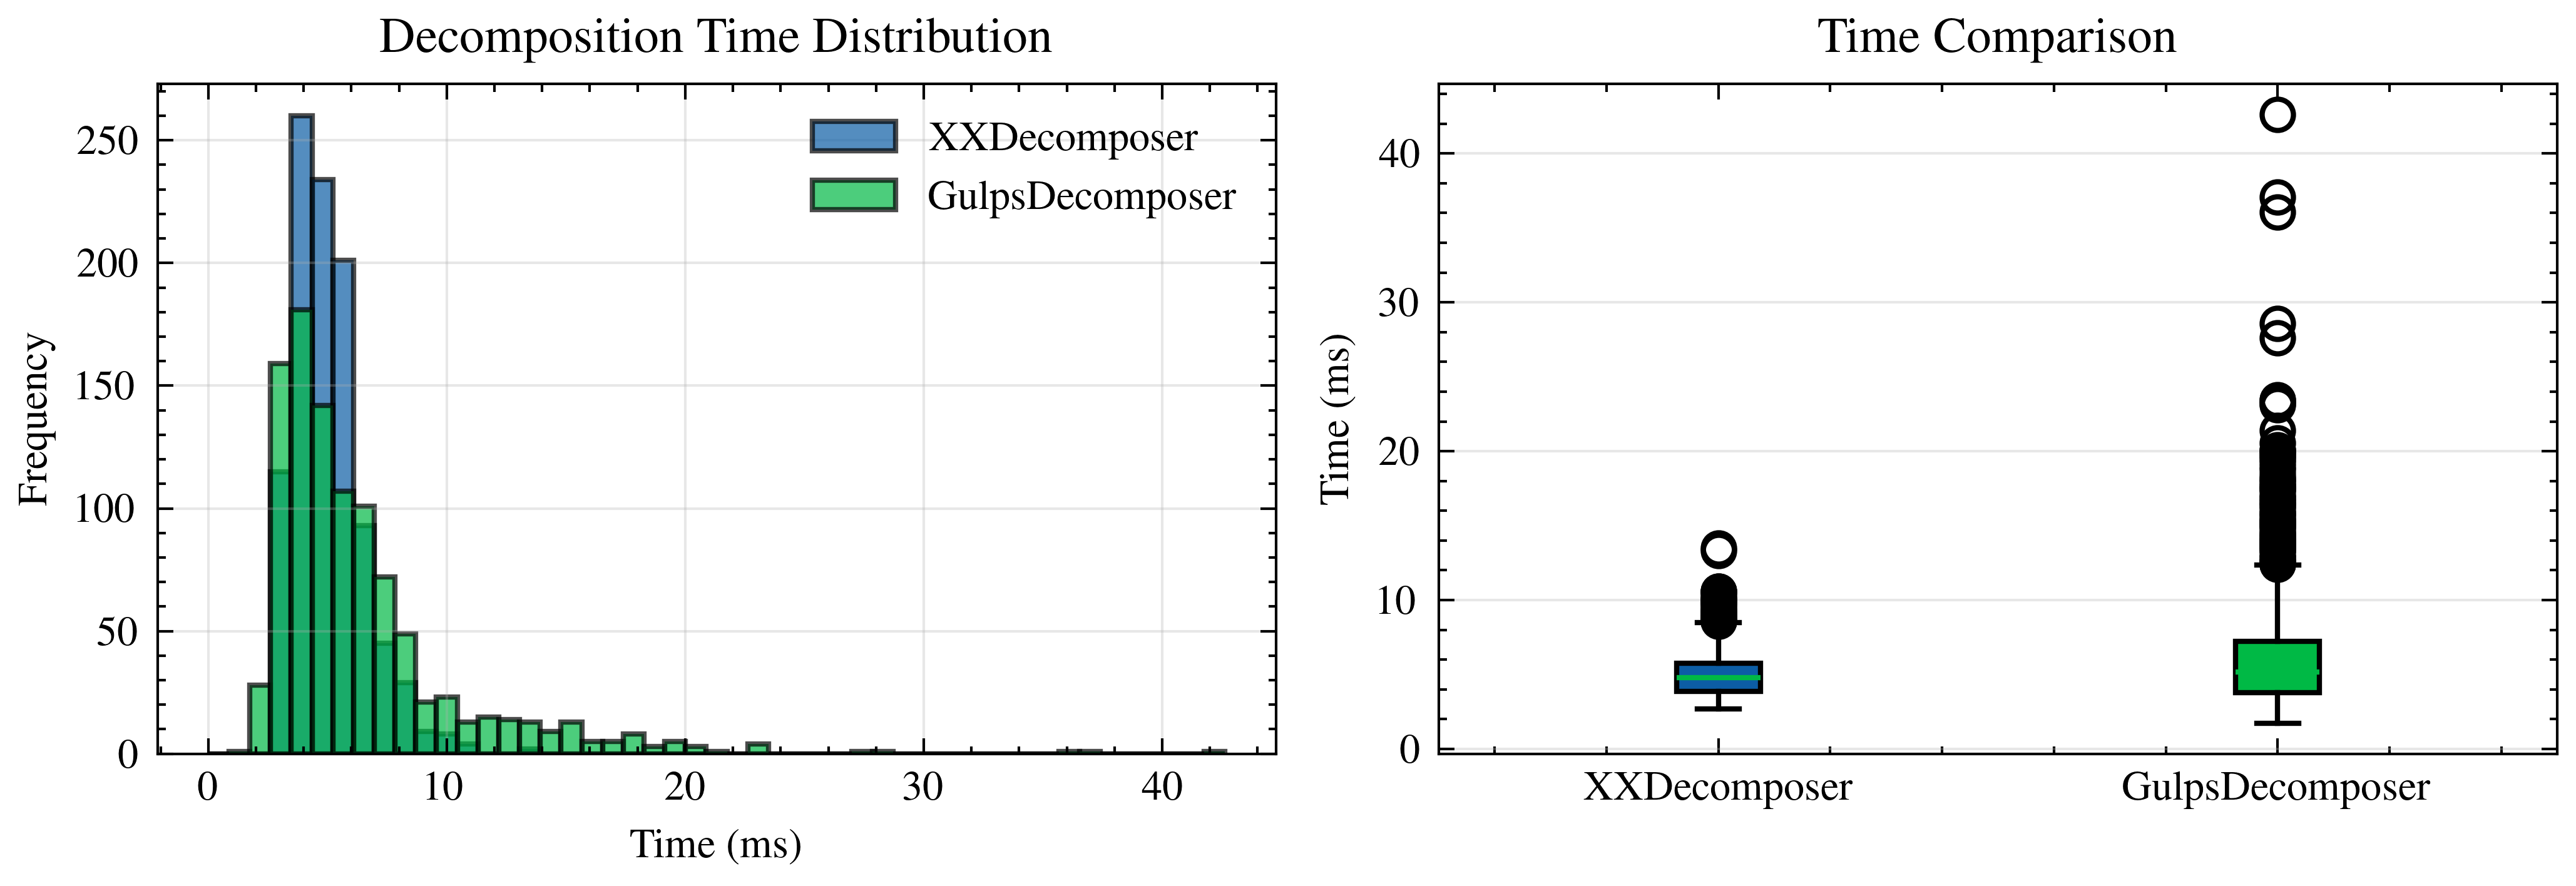

In [34]:
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

    # Histogram of times
    ax = axes[0]
    bins = np.linspace(0, max(xx_times.max(), gulps_times.max()), 50)
    ax.hist(
        xx_times * 1000,
        bins=bins * 1000,
        alpha=0.7,
        label="XXDecomposer",
        edgecolor="black",
    )
    ax.hist(
        gulps_times * 1000,
        bins=bins * 1000,
        alpha=0.7,
        label="GulpsDecomposer",
        edgecolor="black",
    )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.set_title("Decomposition Time Distribution")
    ax.grid(True, alpha=0.3)

    # Box plot comparison
    ax = axes[1]
    bp = ax.boxplot(
        [xx_times * 1000, gulps_times * 1000],
        labels=["XXDecomposer", "GulpsDecomposer"],
        patch_artist=True,
    )
    bp["boxes"][0].set_facecolor("C0")
    bp["boxes"][1].set_facecolor("C1")
    ax.set_ylabel("Time (ms)")
    ax.set_title("Time Comparison")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("benchmark_times.png", dpi=150, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_922389/2552125766.py:23: RuntimeWarning: invalid value encountered in log10
  np.log10(min(inf_xx.min(), inf_gulps.min())),


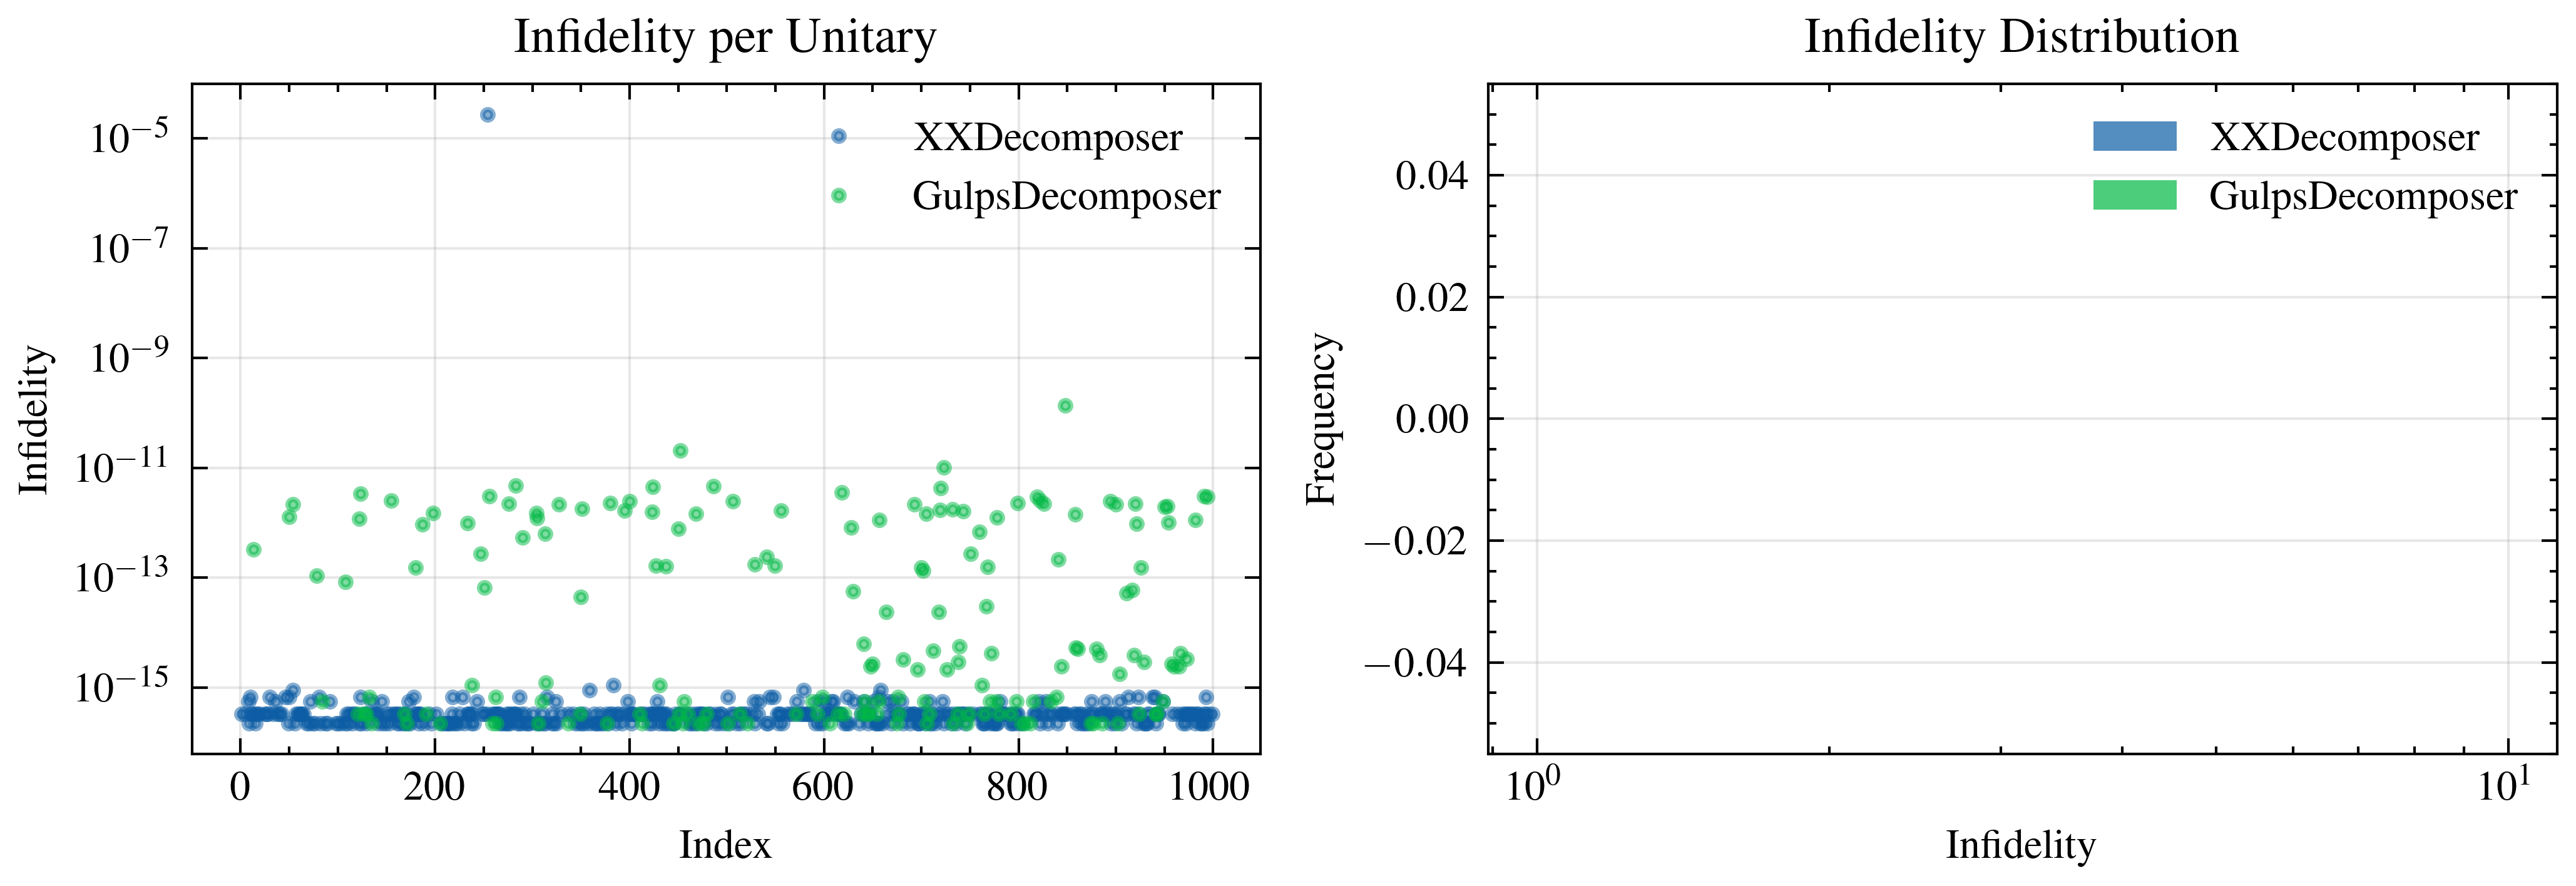

In [35]:
### Visualization: Fidelity Comparison

# %%
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

    # Infidelity scatter
    ax = axes[0]
    ax.plot(1 - xx_fidelities, "o", markersize=2, alpha=0.5, label="XXDecomposer")
    ax.plot(1 - gulps_fidelities, "o", markersize=2, alpha=0.5, label="GulpsDecomposer")
    ax.set_xlabel("Index")
    ax.set_ylabel("Infidelity")
    ax.set_yscale("log")
    ax.legend()
    ax.set_title("Infidelity per Unitary")
    ax.grid(True, alpha=0.3)

    # Infidelity histogram
    ax = axes[1]
    inf_xx = 1 - xx_fidelities
    inf_gulps = 1 - gulps_fidelities
    bins = np.logspace(
        np.log10(min(inf_xx.min(), inf_gulps.min())),
        np.log10(max(inf_xx.max(), inf_gulps.max())),
        30,
    )
    ax.hist(inf_xx, bins=bins, alpha=0.7, label="XXDecomposer")
    ax.hist(inf_gulps, bins=bins, alpha=0.7, label="GulpsDecomposer")
    ax.set_xscale("log")
    ax.set_xlabel("Infidelity")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.set_title("Infidelity Distribution")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("benchmark_fidelities.png", dpi=150, bbox_inches="tight")
    plt.show()


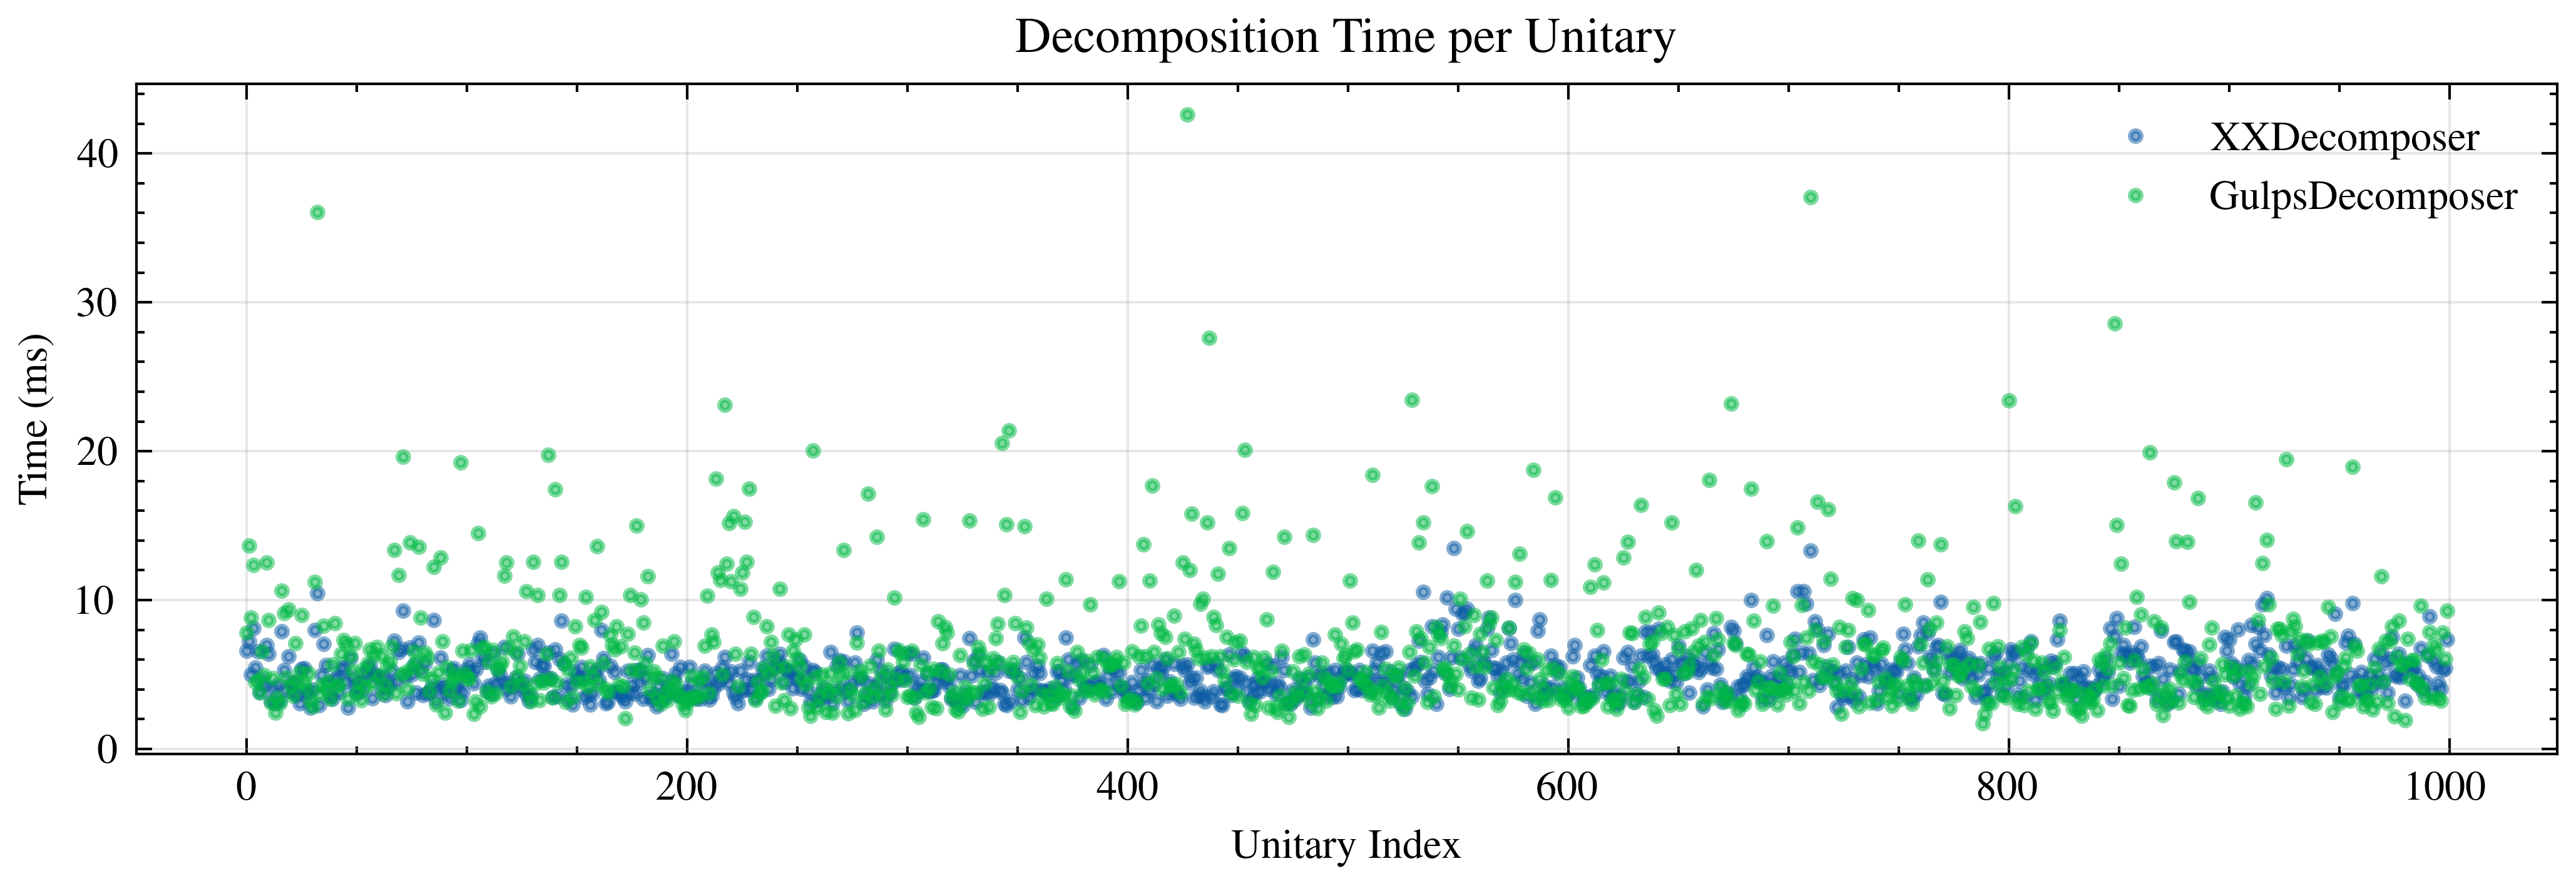

In [36]:
# ### Time vs Index (detect outliers/trends)

# %%
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(7, 2.5))

    ax.plot(xx_times * 1000, "o", markersize=2, alpha=0.5, label="XXDecomposer")
    ax.plot(gulps_times * 1000, "o", markersize=2, alpha=0.5, label="GulpsDecomposer")
    ax.set_xlabel("Unitary Index")
    ax.set_ylabel("Time (ms)")
    ax.legend()
    ax.set_title("Decomposition Time per Unitary")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("benchmark_time_series.png", dpi=150, bbox_inches="tight")
    plt.show()